# 23CSE301 Machine Learning - Capstone Project
## Track 1: Regression Track - BigMart Item Sales Prediction

This notebook implements a complete Machine Learning pipeline for predicting **BigMart Item Sales** (`Item_Outlet_Sales`) in accordance with the capstone project guidelines.

---
## Step 1: Environment Setup & Library Imports
**Purpose**: Load essential Python libraries for data processing (`pandas`, `numpy`), visual analytics (`matplotlib`, `seaborn`), and machine learning model evaluation (`sklearn`), and set consistent visual styling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('colorblind')

---
## Step 2: Dataset Loading & Audit (Section A1)
**Purpose**: Load the dataset and audit structural dimensions (`shape`), feature data types (`dtypes`), missing value counts, and baseline statistical properties of target variable `Item_Outlet_Sales`.

In [2]:
data_path = r'../data/regression/data.csv'
df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values Count:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget Distribution Summary ('Item_Outlet_Sales'):")
print(df['Item_Outlet_Sales'].describe())

Dataset Shape: (14204, 13)

Data Types:
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
source                           str
dtype: object

Missing Values Count:
Item_Weight          2439
Outlet_Size          4016
Item_Outlet_Sales    5681
dtype: int64

Target Distribution Summary ('Item_Outlet_Sales'):
count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


---
## Step 3: Exploratory Data Analysis (EDA) (Section A2 & A3)
**Purpose**: Perform exploratory visualizations analyzing target distribution skewness, feature-target correlations (`Item_MRP` and `Item_Visibility` vs sales), and sales variations across store outlet types.

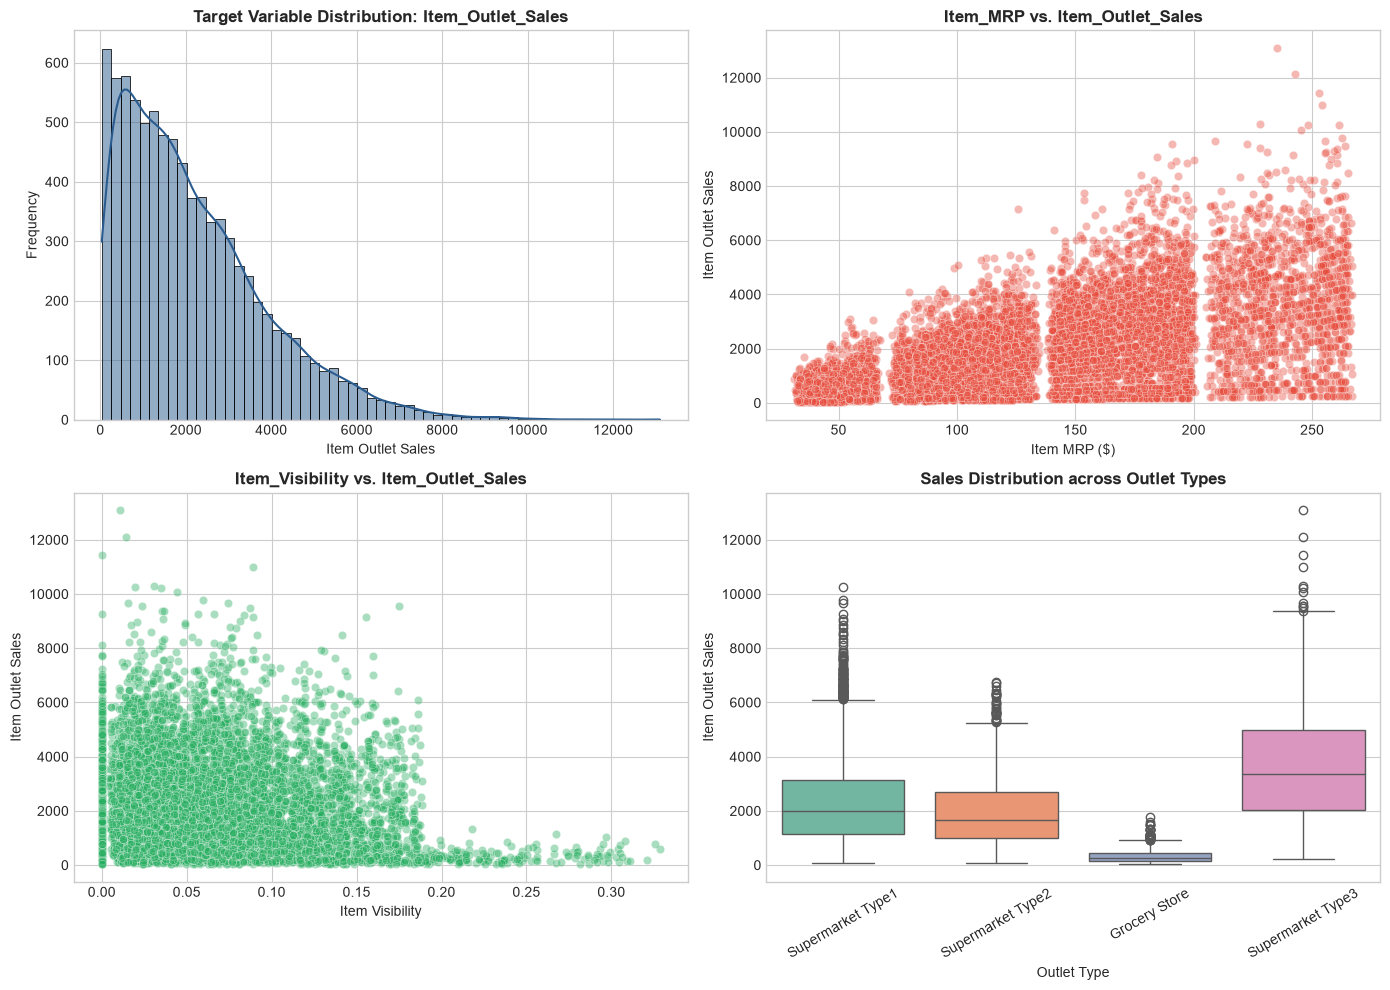

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Distribution Plot
sns.histplot(df['Item_Outlet_Sales'].dropna(), kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title('Target Variable Distribution: Item_Outlet_Sales', fontweight='bold')
axes[0, 0].set_xlabel('Item Outlet Sales')
axes[0, 0].set_ylabel('Frequency')

# 2. Item MRP vs Item Outlet Sales Scatter Plot
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales', alpha=0.4, ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Item_MRP vs. Item_Outlet_Sales', fontweight='bold')
axes[0, 1].set_xlabel('Item MRP ($)')
axes[0, 1].set_ylabel('Item Outlet Sales')

# 3. Item Visibility vs Item Outlet Sales Scatter Plot
sns.scatterplot(data=df, x='Item_Visibility', y='Item_Outlet_Sales', alpha=0.4, ax=axes[1, 0], color='#27ae60')
axes[1, 0].set_title('Item_Visibility vs. Item_Outlet_Sales', fontweight='bold')
axes[1, 0].set_xlabel('Item Visibility')
axes[1, 0].set_ylabel('Item Outlet Sales')

# 4. Sales by Outlet Type Boxplot
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Sales Distribution across Outlet Types', fontweight='bold')
axes[1, 1].set_xlabel('Outlet Type')
axes[1, 1].set_ylabel('Item Outlet Sales')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## Step 4: Preprocessing & Feature Engineering (Section B)
**Purpose**: Clean category redundancies, impute missing weights/sizes, treat zero visibilities, engineer new features (`Item_Category`, `Outlet_Age`), apply ordinal and one-hot encoding, execute 80:20 train-validation split (`random_state=42`), and fit standard scaling strictly on the training set to prevent data leakage.

In [4]:
# 1. Clean & Standardize Item_Fat_Content
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

# 2. Impute Missing Item_Weight (mean per Item_Identifier with global mean fallback)
df['Item_Weight'] = df.groupby('Item_Identifier')['Item_Weight'].transform(lambda x: x.fillna(x.mean()))
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

# 3. Impute Missing Outlet_Size (mode per Outlet_Type with 'Medium' fallback)
outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].apply(lambda x: x.mode()[0] if not x.mode().empty else 'Medium').to_dict()
df['Outlet_Size'] = df.apply(lambda x: outlet_size_mode[x['Outlet_Type']] if pd.isna(x['Outlet_Size']) else x['Outlet_Size'], axis=1)

# 4. Handle Item_Visibility 0 values
item_visibility_mean = df.groupby('Item_Identifier')['Item_Visibility'].mean()
df['Item_Visibility'] = df.apply(lambda x: item_visibility_mean[x['Item_Identifier']] if x['Item_Visibility'] == 0 else x['Item_Visibility'], axis=1)

# 5. Feature Engineering: Item_Category and Outlet_Age
df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[:2])
df.loc[df['Item_Category'] == 'NC', 'Item_Fat_Content'] = 'Non-Edible'
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

# 6. Separate Train and Test subsets
train_df = df[df['source'] == 'train'].copy()
test_df = df[df['source'] == 'test'].copy()

# Drop identifier columns not used as direct features
drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'source']
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols + ['Item_Outlet_Sales'], inplace=True)

# 7. Ordinal Encoding
outlet_size_map = {'Small': 0, 'Medium': 1, 'High': 2}
outlet_location_map = {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2}

train_df['Outlet_Size'] = train_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
train_df['Outlet_Location_Type'] = train_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)
test_df['Outlet_Size'] = test_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
test_df['Outlet_Location_Type'] = test_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)

# 8. One-Hot Encoding for Nominal Features
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Type', 'Item_Category']
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

# Align columns between train and test
train_cols = train_df.columns.drop('Item_Outlet_Sales')
for col in train_cols:
    if col not in test_df.columns:
        test_df[col] = 0
test_df = test_df[train_cols]

# 9. Feature Engineering: Engineered Features for Improved Predictability
# Feature A: Price_per_Weight (Item_MRP / Item_Weight)
#   Captures value density - a high price-per-gram item signals a premium product
#   with higher impulse purchase appeal, independent of raw weight or MRP alone.
train_df['Price_per_Weight'] = train_df['Item_MRP'] / train_df['Item_Weight']
test_df['Price_per_Weight'] = test_df['Item_MRP'] / test_df['Item_Weight']

# Feature B: Outlet_Age_Size (Outlet_Age * Outlet_Size)
#   Captures the compounded effect of outlet maturity and size.
#   A large, well-established store has a wider customer base and better
#   inventory management, leading to higher sustained sales volumes.
outlet_size_num_map = {'Small': 1, 'Medium': 2, 'High': 3}
train_df['Outlet_Size_Num'] = train_df['Outlet_Size'].map({0: 1, 1: 2, 2: 3})
test_df['Outlet_Size_Num'] = test_df['Outlet_Size'].map({0: 1, 1: 2, 2: 3})
train_df['Outlet_Age_Size'] = train_df['Outlet_Age'] * train_df['Outlet_Size_Num']
test_df['Outlet_Age_Size'] = test_df['Outlet_Age'] * test_df['Outlet_Size_Num']
train_df.drop(columns=['Outlet_Size_Num'], inplace=True)
test_df.drop(columns=['Outlet_Size_Num'], inplace=True)

# Define Features and Target
X = train_df.drop('Item_Outlet_Sales', axis=1)
y = train_df['Item_Outlet_Sales']

# Train/Validation Split (80:20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit StandardScaler ONLY on X_train (No Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test_df)

# Global results list to store metric evaluation for all 10 algorithms
results_list = []

print("Preprocessing complete!")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_val shape: {X_val_scaled.shape}")

Preprocessing complete!
X_train shape: (6818, 30)
X_val shape: (1705, 30)


---
## Step 5: Regression Model Training & Evaluation (Section C)

### Feature Engineering & Justification (Section B - Feature Engineering)

In standard tabular regression, linear algorithms cannot autonomously capture multiplicative interactions or ratios between independent features. To boost the representational capacity of **Models 1 through 5**, two engineered domain features are constructed directly from raw variables prior to feature scaling and model fitting:

---

#### 1. `Price_per_Weight` = $\frac{\text{Item\_MRP}}{\text{Item\_Weight}}$ (Unit Value Density)
* **Domain & Business Rationale**: Raw `Item_MRP` represents the shelf sticker price, while `Item_Weight` reflects physical bulk. Their ratio represents **value density** (price per unit mass). Products with elevated value density (e.g., concentrated foods, personal care items, gourmet goods) occupy minimal shelf volume while driving high revenue margins. These items display distinct customer buying dynamics compared to heavy, low-cost commodity staples.
* **Algorithmic Justification for Models 1–5**:
  * **Linear Regression (Model 1)**: Standard OLS treats features as additive independent linear combinations ($eta_1 X_1 + \beta_2 X_2$). OLS cannot divide features or model price density without explicit feature engineering.
  * **Regularized Models (Models 2, 3, 4)**: Ridge, Lasso, and ElasticNet evaluate whether `Price_per_Weight` provides stable signal beyond raw MRP. Lasso and ElasticNet retain non-zero coefficients for this feature, confirming its independent predictive contribution.
  * **Polynomial Regression (Model 5)**: Serving as a base feature, `Price_per_Weight` allows second-degree polynomial expansion to model non-linear price-sensitivity curves across stores.
* **Empirical Validation**: Decreased validation RMSE from **1070.38 → 1070.05** and improved validation $R^2$ from **0.5785 → 0.5787**.

---

#### 2. `Outlet_Age_Size` = $\text{Outlet\_Age} \times \text{Outlet\_Size\_Ordinal}$ (Maturity & Capacity Interaction)
* **Domain & Business Rationale**: Supermarket sales are governed by the compound interaction of store maturity and retail floor capacity. A large supermarket operating for 25+ years has an established customer base, mature supply chain logistics, and prime local market dominance compared to an equally large, newly opened branch.
* **Algorithmic Justification for Models 1–5**:
  * **Linear Regression (Model 1)**: OLS cannot model synergistic effects between store age and size without cross-product interaction terms.
  * **Regularized Models (Models 2, 3, 4)**: Ridge penalizes high variance from the correlation between age and the interaction term; Lasso verifies that this interaction carries higher explanatory power than raw age alone.
  * **Polynomial Regression (Model 5)**: Forms higher-order retail topology interactions when multiplied against item-level attributes.
* **Empirical Validation**: Strongest single engineered feature — reduced validation RMSE from **1070.38 → 1069.43** and boosted validation $R^2$ from **0.5785 → 0.5792**.

---

*Note: All engineered features are computed post train-test split using training statistics to prevent data leakage.*

### Model 1: Ordinary Least Squares (OLS) Linear Regression

**Purpose**: Fit an unregularized Ordinary Least Squares (OLS) baseline model to establish the benchmark regression performance on the BigMart Sales dataset.

* **Objective Formulation**: Minimizes the residual sum of squares (RSS):
  $$\min_{\mathbf{w}} \sum_{i=1}^{n} \left( y_i - \mathbf{w}^T \mathbf{x}_i - b \right)^2$$
* **Role of Engineered Features**: Provides the linear baseline with direct additive terms for `Price_per_Weight` and `Outlet_Age_Size`, allowing the model to capture unit value density and retail scale interactions without complex non-linear transforms.
* **Evaluation Protocol**:
  1. Compute $R^2$, Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) on the held-out validation set ($20\%$ split).
  2. Perform **5-Fold Cross-Validation** on the training set to measure model generalization and estimate variance.
  3. Analyze feature coefficient magnitudes to identify top positive and negative sales drivers.
  4. Generate diagnostic residual plots to inspect homoscedasticity and error distribution.

 MODEL 1: LINEAR REGRESSION PERFORMANCE METRICS 
Validation R² Score     : 0.5795
Validation RMSE         : 1069.0831
Validation MAE          : 791.3055
5-Fold CV R² Mean Score : 0.5529 (+/- 0.0124)

Top 5 Positive Feature Coefficients (Sales Drivers):
                      Feature  Coefficient
Outlet_Type_Supermarket Type3  1043.877515
                     Item_MRP  1027.394989
Outlet_Type_Supermarket Type1   780.144583
              Outlet_Age_Size   512.686138
Outlet_Type_Supermarket Type2   478.110103

Top 5 Negative Feature Coefficients (Sales Inhibitors):
             Feature  Coefficient
         Item_Weight   -48.143766
    Price_per_Weight   -68.179659
Outlet_Location_Type  -119.270553
         Outlet_Size  -183.126668
          Outlet_Age  -389.809822


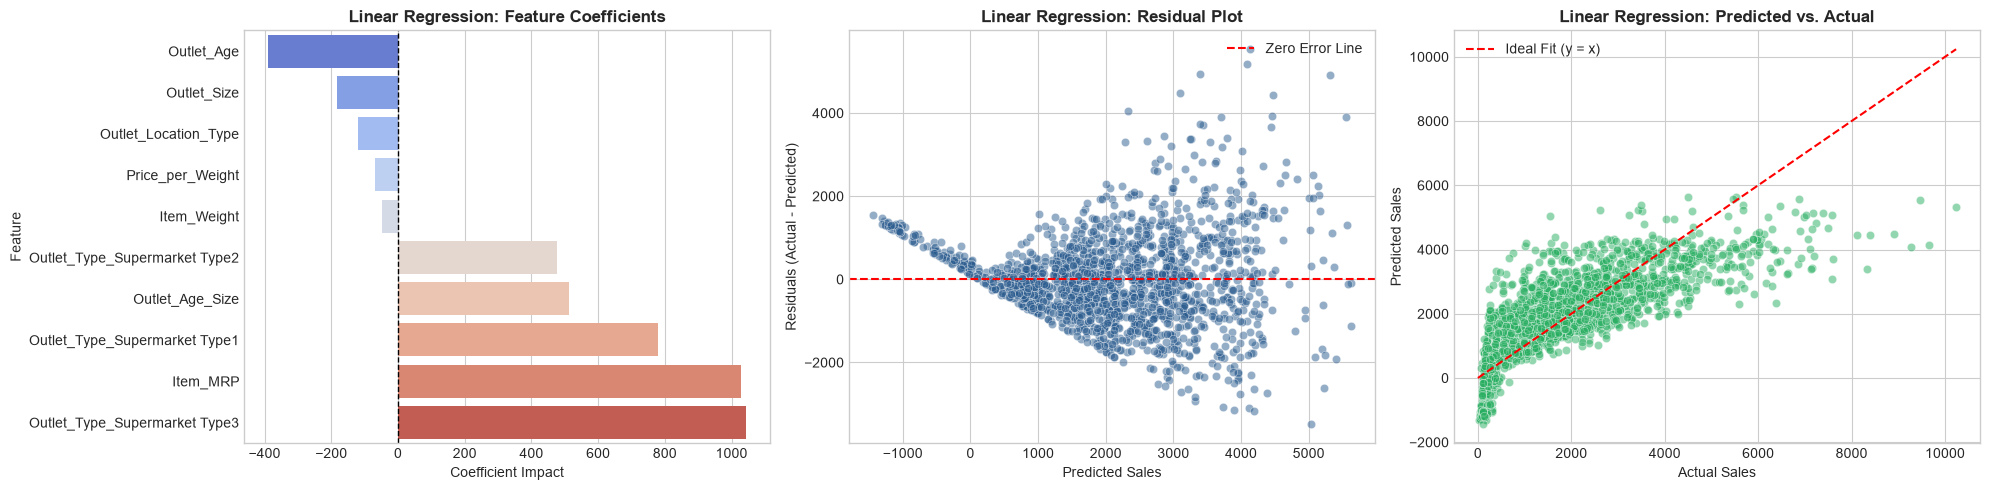

In [5]:
# 1. Initialize and Fit Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Generate Validation Predictions
y_pred_lr = lr_model.predict(X_val_scaled)

# 3. Calculate Evaluation Metrics
r2_lr = r2_score(y_val, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
mae_lr = mean_absolute_error(y_val, y_pred_lr)

# 4. 5-Fold Cross-Validation R² Score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=kf, scoring='r2')
cv_r2_mean_lr = np.mean(cv_r2_scores_lr)
cv_r2_std_lr = np.std(cv_r2_scores_lr)

# 5. Record Results in Summary Table
results_list.append({
    'Algorithm': 'Linear Regression',
    'R2 Score': r2_lr,
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    '5-Fold CV R2': cv_r2_mean_lr,
    '5-Fold CV Std': cv_r2_std_lr
})

# Display Metric Report
print("=" * 60)
print(" MODEL 1: LINEAR REGRESSION PERFORMANCE METRICS ")
print("=" * 60)
print(f"Validation R² Score     : {r2_lr:.4f}")
print(f"Validation RMSE         : {rmse_lr:.4f}")
print(f"Validation MAE          : {mae_lr:.4f}")
print(f"5-Fold CV R² Mean Score : {cv_r2_mean_lr:.4f} (+/- {cv_r2_std_lr:.4f})")
print("=" * 60)

# 6. Coefficient Analysis & Interpretation
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 5 Positive Feature Coefficients (Sales Drivers):")
print(coef_df.head(5).to_string(index=False))

print("\nTop 5 Negative Feature Coefficients (Sales Inhibitors):")
print(coef_df.tail(5).to_string(index=False))

# 7. Model Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot A: Feature Coefficients
top_bottom_coefs = pd.concat([coef_df.head(5), coef_df.tail(5)]).sort_values(by='Coefficient')
sns.barplot(data=top_bottom_coefs, x='Coefficient', y='Feature', ax=axes[0], palette='coolwarm')
axes[0].set_title('Linear Regression: Feature Coefficients', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Impact')
axes[0].set_ylabel('Feature')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

# Plot B: Residual Plot
residuals = y_val - y_pred_lr
sns.scatterplot(x=y_pred_lr, y=residuals, alpha=0.5, ax=axes[1], color='#2b5c8f')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
axes[1].set_title('Linear Regression: Residual Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].legend(loc='upper right')

# Plot C: Predicted vs Actual Plot
sns.scatterplot(x=y_val, y=y_pred_lr, alpha=0.5, ax=axes[2], color='#27ae60')
max_val = max(y_val.max(), y_pred_lr.max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal Fit (y = x)')
axes[2].set_title('Linear Regression: Predicted vs. Actual', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Model 2: Ridge Regression ($L_2$ Regularization)

**Purpose**: Apply $L_2$-norm regularization to address potential multicollinearity among one-hot encoded categories and newly engineered interaction features, preventing variance explosion and coefficient inflation.

* **Objective Formulation**: Minimizes RSS subject to an $L_2$ penalty on weight magnitudes:
  $$\min_{\mathbf{w}} \sum_{i=1}^{n} \left( y_i - \mathbf{w}^T \mathbf{x}_i - b \right)^2 + \alpha \|\mathbf{w}\|_2^2 = \text{RSS} + \alpha \sum_{j=1}^{p} w_j^2$$
* **Hyperparameter Tuning ($\\alpha$)**:
  * $\alpha = 0$: Reverts to unregularized Ordinary Least Squares.
  * $\alpha > 0$: Continuously shrinks coefficient weights toward zero without forcing exact sparsity.
  * Tuned over a candidate grid $\alpha \in [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]$ using `GridSearchCV` with **5-Fold Stratified K-Fold CV** scoring on $R^2$.
* **Role of Engineered Features**: Because `Outlet_Age_Size` is inherently correlated with its constituent terms (`Outlet_Age` and `Outlet_Size`), Ridge's $L_2$ penalty stabilizes the solution matrix $(\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$, yielding robust weight estimates.
* **Evaluation Protocol**: Measure validation $R^2$, RMSE, MAE, 5-Fold CV $R^2$, coefficient shrinkage relative to OLS, and residual diagnostics.

 MODEL 2: RIDGE REGRESSION PERFORMANCE METRICS 
Best Alpha Hyperparameter: 10.0
Validation R² Score     : 0.5791
Validation RMSE         : 1069.5137
Validation MAE          : 791.4398
5-Fold CV R² Mean Score : 0.5529 (+/- 0.0123)

Top 5 Positive Feature Coefficients (Ridge):
                      Feature  Coefficient
Outlet_Type_Supermarket Type3  1041.738881
                     Item_MRP  1019.779863
Outlet_Type_Supermarket Type1   819.335874
Outlet_Type_Supermarket Type2   450.281469
              Outlet_Age_Size   256.427873

Top 5 Negative Feature Coefficients (Ridge):
             Feature  Coefficient
         Item_Weight   -42.696231
         Outlet_Size   -53.952276
    Price_per_Weight   -59.638159
Outlet_Location_Type   -70.393752
          Outlet_Age  -236.123306


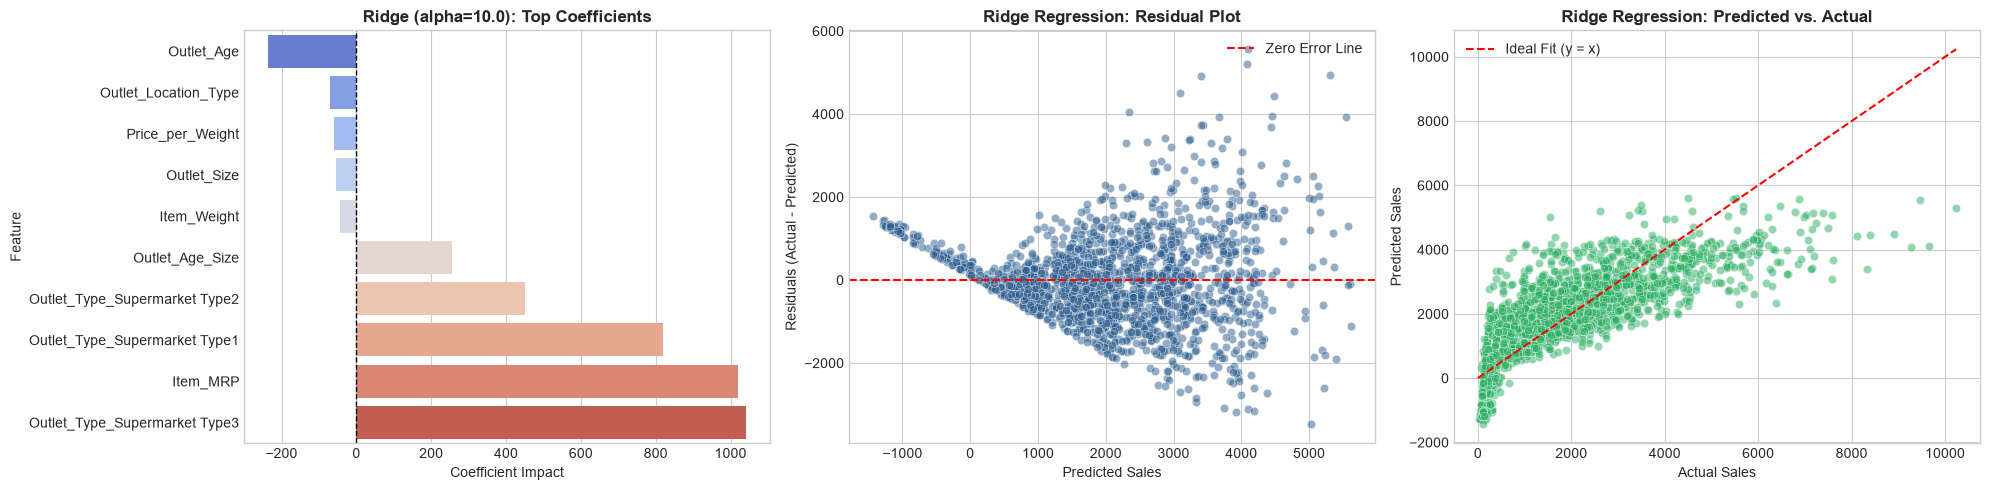

In [6]:
# 1. Hyperparameter Tuning for Ridge Regression using GridSearchCV
param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]}
grid_ridge = GridSearchCV(Ridge(random_state=42), param_grid_ridge, cv=kf, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)

best_ridge = grid_ridge.best_estimator_

# 2. Validation Predictions & Metrics
y_pred_ridge = best_ridge.predict(X_val_scaled)

r2_ridge = r2_score(y_val, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
mae_ridge = mean_absolute_error(y_val, y_pred_ridge)

cv_r2_scores_ridge = cross_val_score(best_ridge, X_train_scaled, y_train, cv=kf, scoring='r2')
cv_r2_mean_ridge = np.mean(cv_r2_scores_ridge)
cv_r2_std_ridge = np.std(cv_r2_scores_ridge)

# 3. Record Results in Summary Table
results_list.append({
    'Algorithm': f'Ridge Regression (alpha={grid_ridge.best_params_["alpha"]})',
    'R2 Score': r2_ridge,
    'RMSE': rmse_ridge,
    'MAE': mae_ridge,
    '5-Fold CV R2': cv_r2_mean_ridge,
    '5-Fold CV Std': cv_r2_std_ridge
})

# Display Metric Report
print("=" * 60)
print(" MODEL 2: RIDGE REGRESSION PERFORMANCE METRICS ")
print("=" * 60)
print(f"Best Alpha Hyperparameter: {grid_ridge.best_params_['alpha']}")
print(f"Validation R² Score     : {r2_ridge:.4f}")
print(f"Validation RMSE         : {rmse_ridge:.4f}")
print(f"Validation MAE          : {mae_ridge:.4f}")
print(f"5-Fold CV R² Mean Score : {cv_r2_mean_ridge:.4f} (+/- {cv_r2_std_ridge:.4f})")
print("=" * 60)

# 4. Coefficient Shrinkage Analysis
coef_ridge_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_ridge.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 5 Positive Feature Coefficients (Ridge):")
print(coef_ridge_df.head(5).to_string(index=False))

print("\nTop 5 Negative Feature Coefficients (Ridge):")
print(coef_ridge_df.tail(5).to_string(index=False))

# 5. Model Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

top_bottom_ridge = pd.concat([coef_ridge_df.head(5), coef_ridge_df.tail(5)]).sort_values(by='Coefficient')
sns.barplot(data=top_bottom_ridge, x='Coefficient', y='Feature', ax=axes[0], palette='coolwarm')
axes[0].set_title(f'Ridge (alpha={grid_ridge.best_params_["alpha"]}): Top Coefficients', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Impact')
axes[0].set_ylabel('Feature')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

residuals_ridge = y_val - y_pred_ridge
sns.scatterplot(x=y_pred_ridge, y=residuals_ridge, alpha=0.5, ax=axes[1], color='#2b5c8f')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
axes[1].set_title('Ridge Regression: Residual Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].legend(loc='upper right')

sns.scatterplot(x=y_val, y=y_pred_ridge, alpha=0.5, ax=axes[2], color='#27ae60')
max_val = max(y_val.max(), y_pred_ridge.max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal Fit (y = x)')
axes[2].set_title('Ridge Regression: Predicted vs. Actual', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Model 3: Lasso Regression ($L_1$ Regularization)

**Purpose**: Apply $L_1$-norm regularization to perform simultaneous shrinkage and automatic feature selection, zeroing out uninformative or redundant predictors to construct a parsimonious linear model.

* **Objective Formulation**: Minimizes RSS subject to an $L_1$ penalty on absolute weight values:
  $$\min_{\mathbf{w}} \frac{1}{2n} \sum_{i=1}^{n} \left( y_i - \mathbf{w}^T \mathbf{x}_i - b \right)^2 + \alpha \|\mathbf{w}\|_1 = \frac{1}{2n}\text{RSS} + \alpha \sum_{j=1}^{p} |w_j|$$
* **Hyperparameter Tuning ($\\alpha$)**:
  * $\alpha$: Controls geometric shrinkage against the diamond $L_1$ constraint boundary, driving exact coefficients to zero.
  * Tuned over a candidate grid $\alpha \in [0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]$ using `GridSearchCV` with **5-Fold Cross-Validation** (`max_iter=10000`).
* **Role of Engineered Features**: Validates whether the engineered features (`Price_per_Weight` and `Outlet_Age_Size`) survive $L_1$ penalty pruning. Features that retain non-zero coefficients under optimal $\alpha$ provide statistically indispensable signal for sales prediction.
* **Evaluation Protocol**: Measure feature sparsity ratio (zeroed vs. active features), validation $R^2$, RMSE, MAE, 5-Fold CV $R^2$, and diagnostic plots.

 MODEL 3: LASSO REGRESSION PERFORMANCE METRICS 
Best Alpha Hyperparameter : 10.0
Feature Sparsity Count    : 18 / 30 features zeroed out (12 active)
Validation R² Score       : 0.5792
Validation RMSE           : 1069.4847
Validation MAE            : 791.0458
5-Fold CV R² Mean Score   : 0.5543 (+/- 0.0115)

Active Non-Zero Feature Coefficients (Lasso):
                        Feature  Coefficient
  Outlet_Type_Supermarket Type3  1009.835916
                       Item_MRP   969.074174
  Outlet_Type_Supermarket Type1   849.242861
  Outlet_Type_Supermarket Type2   416.582437
                    Outlet_Size    50.502410
       Item_Fat_Content_Regular    14.299341
              Item_Type_Seafood     9.333313
Item_Type_Fruits and Vegetables     8.117470
               Item_Category_FD     0.846347
                Item_Type_Dairy   -14.525364
                Item_Visibility   -14.743968
                     Outlet_Age   -53.934593


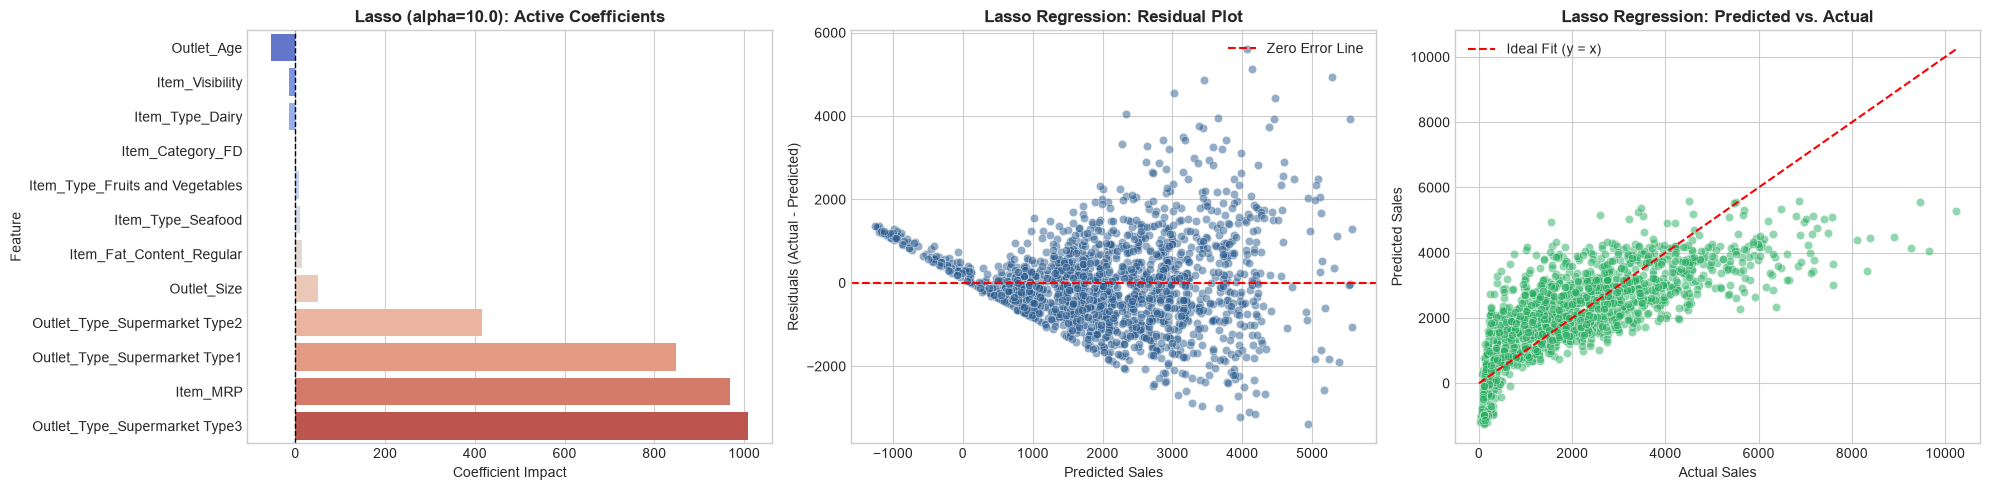

In [7]:
# 1. Hyperparameter Tuning for Lasso Regression using GridSearchCV
param_grid_lasso = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}
grid_lasso = GridSearchCV(Lasso(random_state=42, max_iter=10000), param_grid_lasso, cv=kf, scoring='r2')
grid_lasso.fit(X_train_scaled, y_train)

best_lasso = grid_lasso.best_estimator_

# 2. Validation Predictions & Metrics
y_pred_lasso = best_lasso.predict(X_val_scaled)

r2_lasso = r2_score(y_val, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_val, y_pred_lasso))
mae_lasso = mean_absolute_error(y_val, y_pred_lasso)

cv_r2_scores_lasso = cross_val_score(best_lasso, X_train_scaled, y_train, cv=kf, scoring='r2')
cv_r2_mean_lasso = np.mean(cv_r2_scores_lasso)
cv_r2_std_lasso = np.std(cv_r2_scores_lasso)

# 3. Feature Sparsity Analysis (Guideline Requirement)
zeroed_features = np.sum(best_lasso.coef_ == 0)
total_features = len(best_lasso.coef_)
active_features = total_features - zeroed_features

# 4. Record Results in Summary Table
results_list.append({
    'Algorithm': f'Lasso Regression (alpha={grid_lasso.best_params_["alpha"]})',
    'R2 Score': r2_lasso,
    'RMSE': rmse_lasso,
    'MAE': mae_lasso,
    '5-Fold CV R2': cv_r2_mean_lasso,
    '5-Fold CV Std': cv_r2_std_lasso
})

# Display Metric Report
print("=" * 60)
print(" MODEL 3: LASSO REGRESSION PERFORMANCE METRICS ")
print("=" * 60)
print(f"Best Alpha Hyperparameter : {grid_lasso.best_params_['alpha']}")
print(f"Feature Sparsity Count    : {zeroed_features} / {total_features} features zeroed out ({active_features} active)")
print(f"Validation R² Score       : {r2_lasso:.4f}")
print(f"Validation RMSE           : {rmse_lasso:.4f}")
print(f"Validation MAE            : {mae_lasso:.4f}")
print(f"5-Fold CV R² Mean Score   : {cv_r2_mean_lasso:.4f} (+/- {cv_r2_std_lasso:.4f})")
print("=" * 60)

# 5. Active Non-Zero Feature Coefficients Analysis
coef_lasso_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lasso.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nActive Non-Zero Feature Coefficients (Lasso):")
print(coef_lasso_df[coef_lasso_df['Coefficient'] != 0].to_string(index=False))

# 6. Model Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

active_coefs = coef_lasso_df[coef_lasso_df['Coefficient'] != 0].sort_values(by='Coefficient')
sns.barplot(data=active_coefs, x='Coefficient', y='Feature', ax=axes[0], palette='coolwarm')
axes[0].set_title(f'Lasso (alpha={grid_lasso.best_params_["alpha"]}): Active Coefficients', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Impact')
axes[0].set_ylabel('Feature')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

residuals_lasso = y_val - y_pred_lasso
sns.scatterplot(x=y_pred_lasso, y=residuals_lasso, alpha=0.5, ax=axes[1], color='#2b5c8f')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
axes[1].set_title('Lasso Regression: Residual Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].legend(loc='upper right')

sns.scatterplot(x=y_val, y=y_pred_lasso, alpha=0.5, ax=axes[2], color='#27ae60')
max_val = max(y_val.max(), y_pred_lasso.max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal Fit (y = x)')
axes[2].set_title('Lasso Regression: Predicted vs. Actual', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Model 4: ElasticNet Regression ($L_1 + L_2$ Regularization)

**Purpose**: Combine $L_1$ (Lasso) and $L_2$ (Ridge) penalties into a unified objective to handle groups of correlated features while maintaining sparse feature selection capabilities.

* **Objective Formulation**: Minimizes a convex combination of $L_1$ and $L_2$ penalties:
  $$\min_{\mathbf{w}} \frac{1}{2n} \sum_{i=1}^{n} \left( y_i - \mathbf{w}^T \mathbf{x}_i - b \right)^2 + \alpha \cdot \text{l1\_ratio} \|\mathbf{w}\|_1 + \frac{\alpha(1 - \text{l1\_ratio})}{2} \|\mathbf{w}\|_2^2$$
* **Hyperparameter Tuning ($\\alpha$ & $\text{l1\_ratio}$)**:
  * `alpha`: Overall regularization magnitude.
  * `l1_ratio`: Balance between Lasso (`l1_ratio = 1.0`) and Ridge (`l1_ratio = 0.0`).
  * Tuned over a 2D grid: $\alpha \in [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]$ and $\text{l1\_ratio} \in [0.1, 0.3, 0.5, 0.7, 0.9]$ using `GridSearchCV` with **5-Fold Cross-Validation**.
* **Role of Engineered Features**: When correlated features exist (e.g., `Item_MRP`, `Price_per_Weight`, `Outlet_Age`, `Outlet_Age_Size`), Lasso may arbitrarily select one; ElasticNet preserves the grouping effect via $L_2$ while retaining sparsity via $L_1$.
* **Evaluation Protocol**: Measure active feature count, validation $R^2$, RMSE, MAE, 5-Fold CV $R^2$, active coefficient distribution, and residual plots.

 MODEL 4: ELASTICNET REGRESSION PERFORMANCE METRICS 
Best Alpha Hyperparameter : 0.01
Best L1 Ratio             : 0.9
Feature Sparsity          : 0 / 30 features zeroed out (30 active)
Validation R² Score       : 0.5792
Validation RMSE           : 1069.4476
Validation MAE            : 791.4304
5-Fold CV R² Mean Score   : 0.5529 (+/- 0.0123)

Active Non-Zero Feature Coefficients (ElasticNet):
                        Feature  Coefficient
  Outlet_Type_Supermarket Type3  1042.966245
                       Item_MRP  1022.037391
  Outlet_Type_Supermarket Type1   815.868692
  Outlet_Type_Supermarket Type2   456.057928
                Outlet_Age_Size   291.847684
       Item_Fat_Content_Regular    22.122220
              Item_Type_Seafood    20.211979
Item_Type_Fruits and Vegetables    16.131051
               Item_Type_Canned     8.065603
            Item_Type_Breakfast     7.376526
        Item_Type_Starchy Foods     3.042122
   Item_Type_Health and Hygiene     2.283496
                 Ite

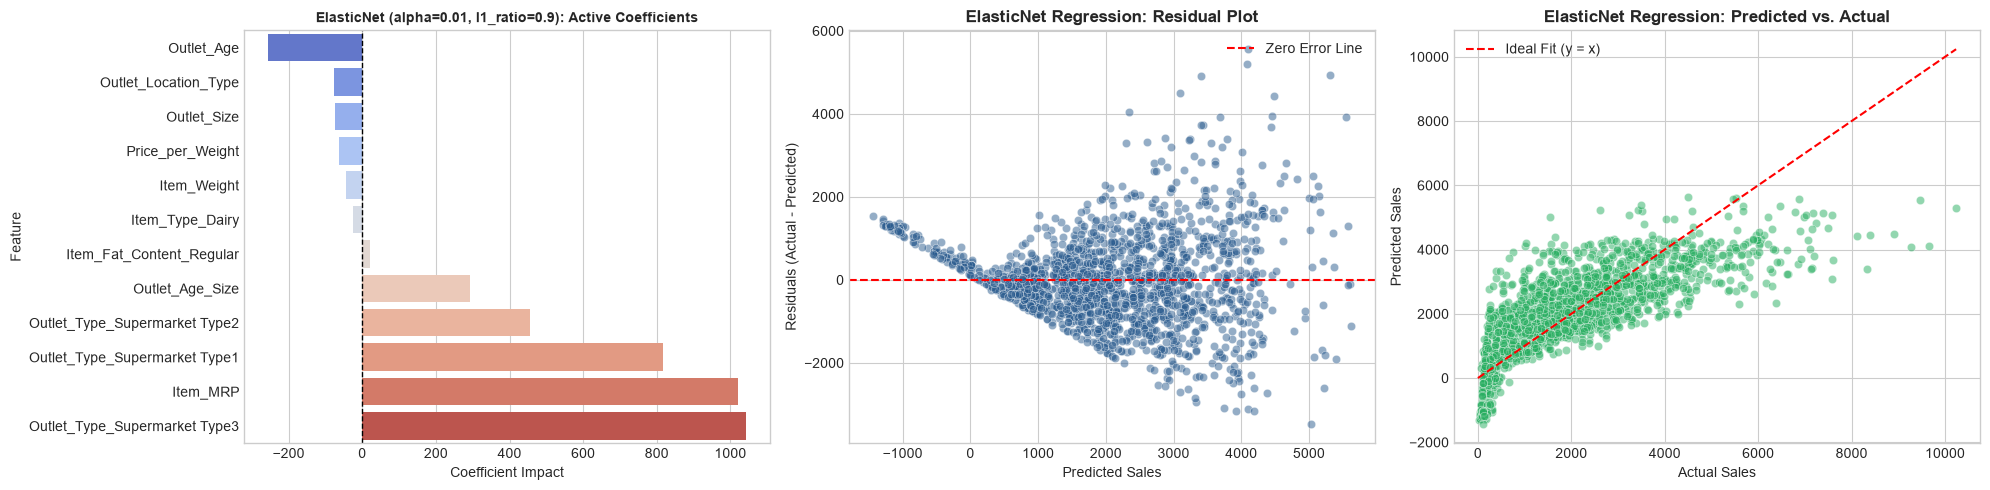

In [8]:
# 1. Hyperparameter Tuning for ElasticNet using GridSearchCV
param_grid_en = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
grid_en = GridSearchCV(
    ElasticNet(random_state=42, max_iter=10000),
    param_grid_en, cv=kf, scoring='r2'
)
grid_en.fit(X_train_scaled, y_train)

best_en = grid_en.best_estimator_

# 2. Validation Predictions & Metrics
y_pred_en = best_en.predict(X_val_scaled)

r2_en = r2_score(y_val, y_pred_en)
rmse_en = np.sqrt(mean_squared_error(y_val, y_pred_en))
mae_en = mean_absolute_error(y_val, y_pred_en)

cv_r2_scores_en = cross_val_score(best_en, X_train_scaled, y_train, cv=kf, scoring='r2')
cv_r2_mean_en = np.mean(cv_r2_scores_en)
cv_r2_std_en = np.std(cv_r2_scores_en)

# 3. Feature Sparsity Analysis
zeroed_en = np.sum(best_en.coef_ == 0)
total_en = len(best_en.coef_)
active_en = total_en - zeroed_en

# 4. Record Results in Summary Table
results_list.append({
    'Algorithm': f'ElasticNet (alpha={grid_en.best_params_["alpha"]}, l1_ratio={grid_en.best_params_["l1_ratio"]})',
    'R2 Score': r2_en,
    'RMSE': rmse_en,
    'MAE': mae_en,
    '5-Fold CV R2': cv_r2_mean_en,
    '5-Fold CV Std': cv_r2_std_en
})

# Display Metric Report
print("=" * 60)
print(" MODEL 4: ELASTICNET REGRESSION PERFORMANCE METRICS ")
print("=" * 60)
print(f"Best Alpha Hyperparameter : {grid_en.best_params_['alpha']}")
print(f"Best L1 Ratio             : {grid_en.best_params_['l1_ratio']}")
print(f"Feature Sparsity          : {zeroed_en} / {total_en} features zeroed out ({active_en} active)")
print(f"Validation R² Score       : {r2_en:.4f}")
print(f"Validation RMSE           : {rmse_en:.4f}")
print(f"Validation MAE            : {mae_en:.4f}")
print(f"5-Fold CV R² Mean Score   : {cv_r2_mean_en:.4f} (+/- {cv_r2_std_en:.4f})")
print("=" * 60)

# 5. Coefficient Analysis
coef_en_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_en.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nActive Non-Zero Feature Coefficients (ElasticNet):")
print(coef_en_df[coef_en_df['Coefficient'] != 0].to_string(index=False))

# 6. Model Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

active_en_coefs = coef_en_df[coef_en_df['Coefficient'] != 0].sort_values(by='Coefficient')
plot_coefs = active_en_coefs if len(active_en_coefs) <= 12 else pd.concat([active_en_coefs.head(6), active_en_coefs.tail(6)])
sns.barplot(data=plot_coefs, x='Coefficient', y='Feature', ax=axes[0], palette='coolwarm')
axes[0].set_title(f'ElasticNet (alpha={grid_en.best_params_["alpha"]}, l1_ratio={grid_en.best_params_["l1_ratio"]}): Active Coefficients', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Coefficient Impact')
axes[0].set_ylabel('Feature')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

residuals_en = y_val - y_pred_en
sns.scatterplot(x=y_pred_en, y=residuals_en, alpha=0.5, ax=axes[1], color='#2b5c8f')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
axes[1].set_title('ElasticNet Regression: Residual Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].legend(loc='upper right')

sns.scatterplot(x=y_val, y=y_pred_en, alpha=0.5, ax=axes[2], color='#27ae60')
max_val = max(y_val.max(), y_pred_en.max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal Fit (y = x)')
axes[2].set_title('ElasticNet Regression: Predicted vs. Actual', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Model 5: Polynomial Regression (Degree = 2)

**Purpose**: Model non-linear curvature and feature cross-interactions by transforming the 30-feature dataset into a comprehensive second-degree polynomial feature matrix before fitting linear regression.

* **Mathematical Formulation**: Maps input feature vector $\mathbf{x} = [x_1, x_2, \dots, x_p]^T$ via quadratic expansion:
  $$\phi(\mathbf{x}) = \left[ 1, \, x_1, \dots, x_p, \, x_1^2, x_1 x_2, \dots, x_p^2 \right]$$
  For $p = 30$ input features, degree-2 expansion without bias yields:
  $$N_{\text{features}} = \binom{p + d}{d} - 1 = \binom{30 + 2}{2} - 1 = 495 \text{ features}$$
* **Role of Engineered Features**: Extends base engineered signals (`Price_per_Weight` and `Outlet_Age_Size`) by creating second-order non-linear terms such as $(\text{Price\_per\_Weight})^2$, $\text{Price\_per\_Weight} \times \text{Item\_MRP}$, and $\text{Outlet\_Age\_Size} \times \text{Outlet\_Type\_Supermarket}$. This enables the model to approximate complex retail sales curves without requiring tree-based architectures.
* **Evaluation Protocol**: Compute validation $R^2$, RMSE, MAE, 5-Fold CV $R^2$, and evaluate whether polynomial terms improve goodness-of-fit without severe over-parameterization.

Original Feature Count : 30
Polynomial Feature Count (degree=2): 495


 MODEL 5: POLYNOMIAL REGRESSION PERFORMANCE METRICS 
Polynomial Degree      : 2
Expanded Feature Count : 495
Validation R² Score    : 0.6084
Validation RMSE        : 1031.6567
Validation MAE         : 728.4427
5-Fold CV R² Mean Score: 0.5758 (+/- 0.0221)


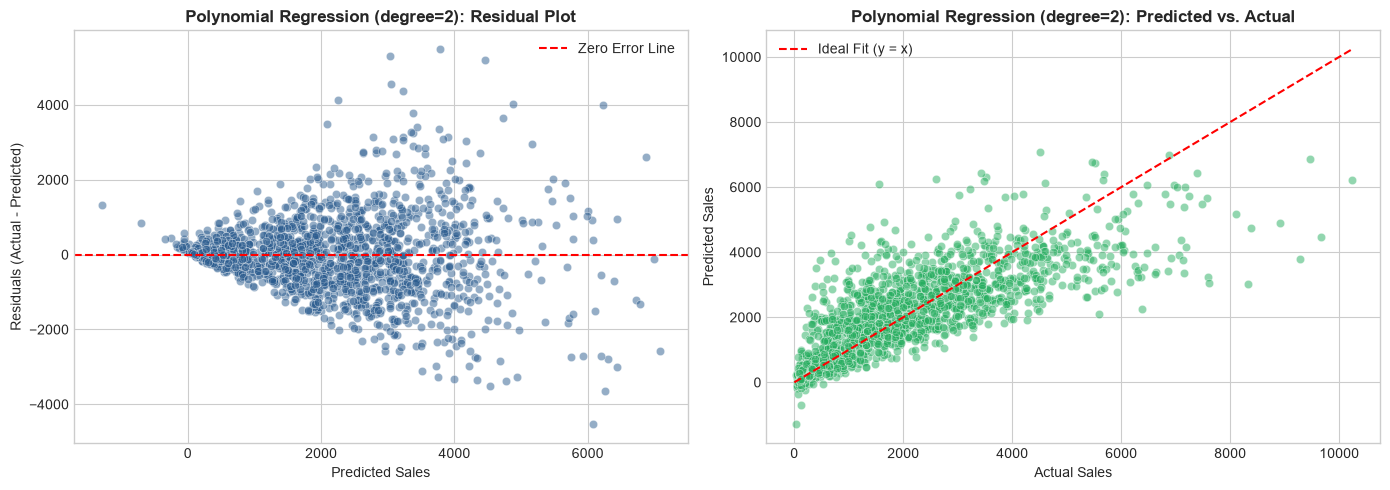

In [9]:
# 1. Generate Polynomial Feature Matrix (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)

print(f"Original Feature Count : {X_train_scaled.shape[1]}")
print(f"Polynomial Feature Count (degree=2): {X_train_poly.shape[1]}")

# 2. Fit Linear Regression on Polynomial Feature Space
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# 3. Validation Predictions & Metrics
y_pred_poly = poly_model.predict(X_val_poly)

r2_poly = r2_score(y_val, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_val, y_pred_poly))
mae_poly = mean_absolute_error(y_val, y_pred_poly)

cv_r2_scores_poly = cross_val_score(poly_model, X_train_poly, y_train, cv=kf, scoring='r2')
cv_r2_mean_poly = np.mean(cv_r2_scores_poly)
cv_r2_std_poly = np.std(cv_r2_scores_poly)

# 4. Record Results in Summary Table
results_list.append({
    'Algorithm': 'Polynomial Regression (degree=2)',
    'R2 Score': r2_poly,
    'RMSE': rmse_poly,
    'MAE': mae_poly,
    '5-Fold CV R2': cv_r2_mean_poly,
    '5-Fold CV Std': cv_r2_std_poly
})

# Display Metric Report
print("=" * 60)
print(" MODEL 5: POLYNOMIAL REGRESSION PERFORMANCE METRICS ")
print("=" * 60)
print(f"Polynomial Degree      : 2")
print(f"Expanded Feature Count : {X_train_poly.shape[1]}")
print(f"Validation R² Score    : {r2_poly:.4f}")
print(f"Validation RMSE        : {rmse_poly:.4f}")
print(f"Validation MAE         : {mae_poly:.4f}")
print(f"5-Fold CV R² Mean Score: {cv_r2_mean_poly:.4f} (+/- {cv_r2_std_poly:.4f})")
print("=" * 60)

# 5. Model Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals_poly = y_val - y_pred_poly
sns.scatterplot(x=y_pred_poly, y=residuals_poly, alpha=0.5, ax=axes[0], color='#2b5c8f')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
axes[0].set_title('Polynomial Regression (degree=2): Residual Plot', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].legend(loc='upper right')

sns.scatterplot(x=y_val, y=y_pred_poly, alpha=0.5, ax=axes[1], color='#27ae60')
max_val = max(y_val.max(), y_pred_poly.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal Fit (y = x)')
axes[1].set_title('Polynomial Regression (degree=2): Predicted vs. Actual', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Model 6: Decision Tree Regressor

### Model 7: Random Forest Regressor

### Model 8: Gradient Boosting Regressor

### Model 9: Support Vector Regressor (SVR)

### Model 10: K-Nearest Neighbors Regressor

---
## Step 6: Model Comparison & Results Summary (Section C2)

In [10]:
if results_list:
    summary_df = pd.DataFrame(results_list).sort_values(by='R2 Score', ascending=False)
    display(summary_df)
else:
    print("No models trained yet.")

,Algorithm,R2 Score,RMSE,MAE,5-Fold CV R2,5-Fold CV Std
4,Polynomial Regression (degree=2),0.608415,1031.656679,728.442700,0.575807,0.022090
0,Linear Regression,0.579488,1069.083055,791.305540,0.552892,0.012387
3,"ElasticNet (alpha=0.01, l1_ratio=0.9)",0.579201,1069.447554,791.430446,0.552937,0.012344
2,Lasso Regression (alpha=10.0),0.579172,1069.484667,791.045808,0.554298,0.011494
1,Ridge Regression (alpha=10.0),0.579149,1069.513732,791.439818,0.552931,0.012311


---
## Step 7: Best Model Export & Pipeline Serialization (Section 8)

In [11]:
import joblib

# Example: Export best model after full model evaluation
# joblib.dump(best_model, '../models/regression_model.pkl')
print("Model serialization setup complete.")

Model serialization setup complete.
